# LOAN APPROVAL PREDICTION PROJECT

In [ ]:
# Step 1: Data Collection and Exploration
# Step 1.1: Import libraries and load the dataset using Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the labelled loan dataset
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

# Total number of rows and columns dataset contains
print("Shape:", df.shape)
# Show the first 5 rows to understand the structure
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Step 1.2: Check data types, non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# Step 1.3: Statistical summary of the dataset
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# Step 1.4: Finding missing values per column
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
# Step 1.5: Finding total number of duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Step 1.6: Checking target variables
print("\nTarget distribution (Y = approved, N = rejected):")
print(df["Loan_Status"].value_counts())


Target distribution (Y = approved, N = rejected):
Loan_Status
Y    422
N    192
Name: count, dtype: int64


## Step 2: Data Cleaning and Transformation

In [ ]:
# Step 2: Data Cleaning and Transformation
# Step 2.1: Removing duplicated rows
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (614, 13)


In [ ]:
# Step 2.2: Handling missing values
# Fill categorical columns with mode (most frequent value)
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns with median (safe from outliers)
num_cols = ["LoanAmount", "Loan_Amount_Term"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Step 2.3: Verify that no missing values remain
print(df.isnull().sum())
print("Shape after cleaning:", df.shape)

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
Shape after cleaning: (614, 13)


In [ ]:
# Step 2.4: Encode categorical variables so the model can use them
# Binary Yes/No and Male/Female columns -> 1/0
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})  # target: 1 = approved, 0 = rejected

# Dependents: "3+" means 3 or more, so convert it to 3 and make the column numeric
df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

# Property_Area has 3 categories with no natural order, so use one-hot encoding
df = pd.get_dummies(df, columns=["Property_Area"], drop_first=True, dtype=int)

# Loan_ID is only an identifier with no useful information, so drop it
df = df.drop("Loan_ID", axis=1)

# Verify: every column should now be numeric
print(df.dtypes)
print("Shape:", df.shape)
df.head()

Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
dtype: object
Shape: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,1


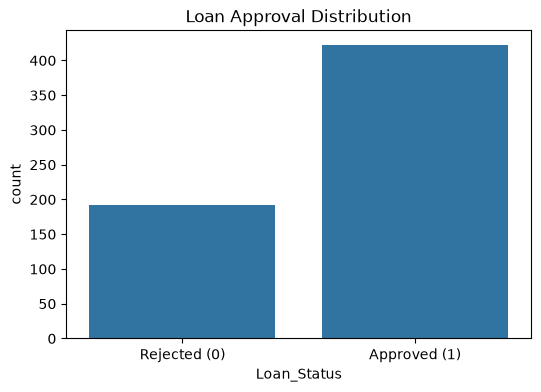

In [ ]:
# Step 3: Exploratory Data Analysis (EDA)
# Step 3.1: Target distribution — is the data balanced?
plt.figure(figsize=(6, 4))
sns.countplot(x="Loan_Status", data=df)
plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])
plt.title("Loan Approval Distribution")
plt.show()

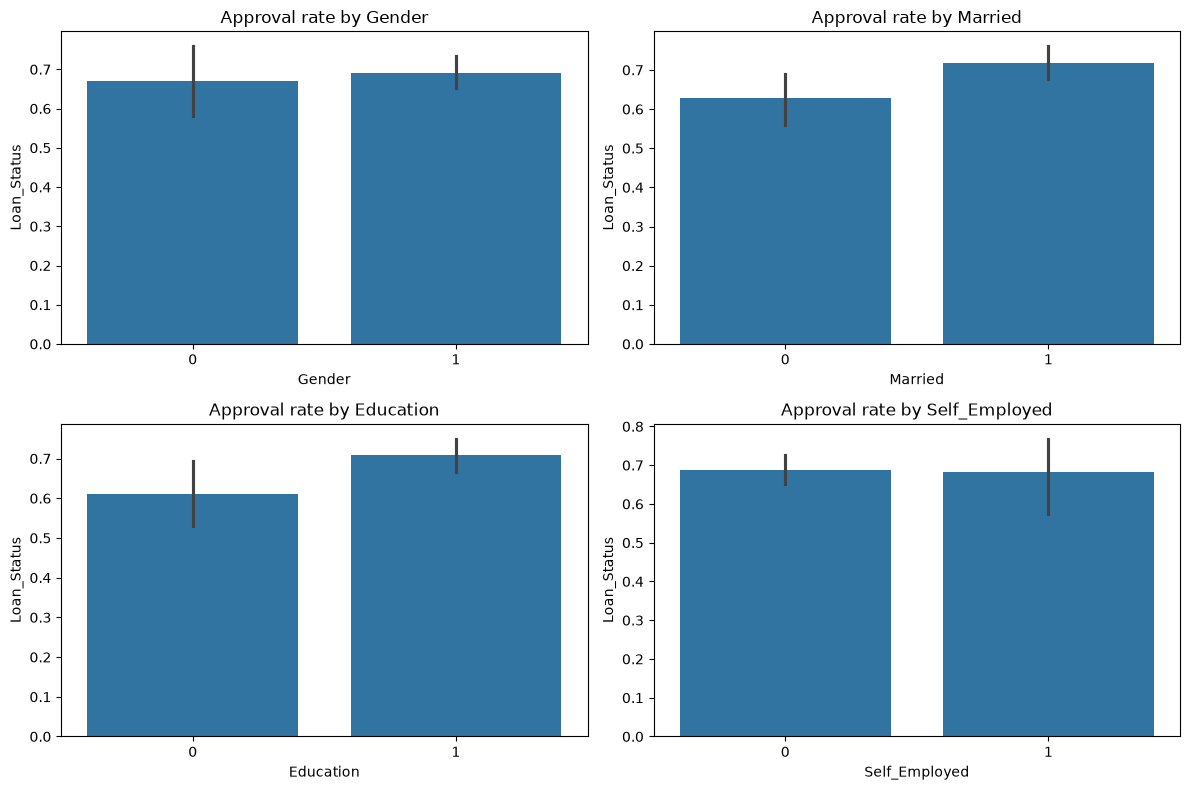

In [ ]:
# Step 3.2: Approval rate for each categorical feature (Credit History shown separately)
cat_features = ["Gender", "Married", "Education", "Self_Employed"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.barplot(x=col, y="Loan_Status", data=df, ax=axes[i])
    axes[i].set_title(f"Approval rate by {col}")
plt.tight_layout()
plt.show()


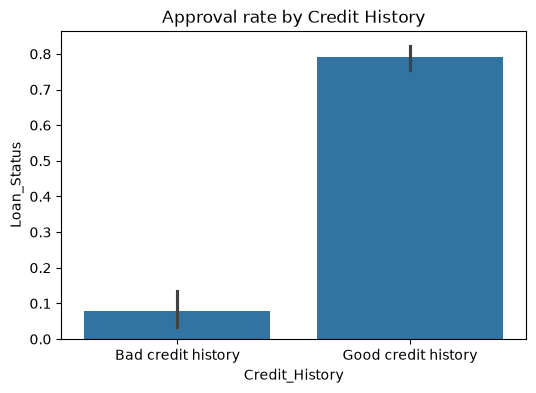

In [ ]:
# Step 3.3: Approval rate by credit history
plt.figure(figsize=(6, 4))
sns.barplot(x="Credit_History", y="Loan_Status", data=df)
plt.xticks([0, 1], ["Bad credit history", "Good credit history"])
plt.title("Approval rate by Credit History")
plt.show()


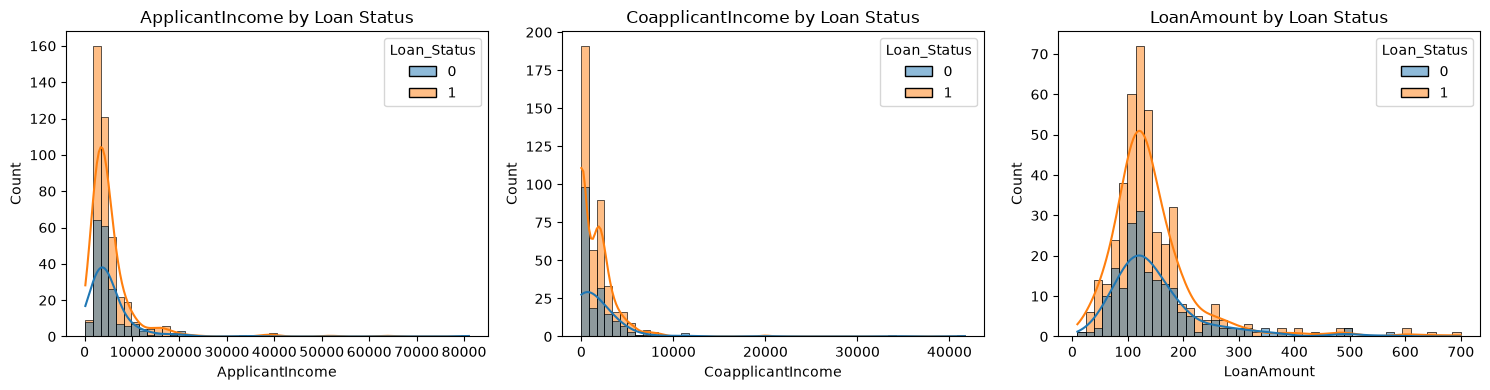

In [ ]:
# Step 3.4: Numeric feature distributions split by loan status
num_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue="Loan_Status", kde=True, ax=axes[i])
    axes[i].set_title(f"{col} by Loan Status")
plt.tight_layout()
plt.show()

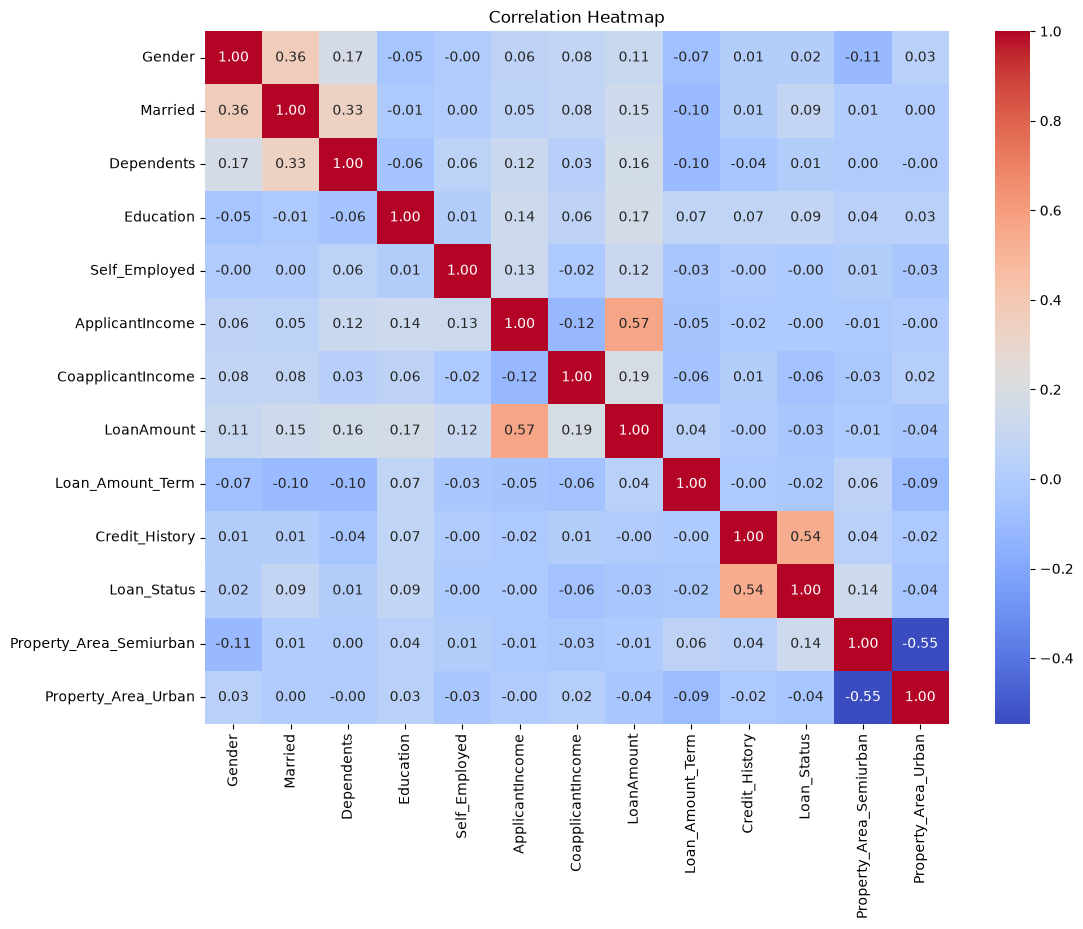

In [ ]:
# Step 3.4: Correlation heatmap — relationships between all variables
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Key findings from EDA
1. Majority of loan approval is higher than loan rejected by the applicant. so the data is slightly imbalanced.
2. Credit history has the strongest relation with approval — applicants with good credit history are approved far more often.
3. Applicants with higher income and graduate education also have better approval chances.
4. ApplicantIncome and CoapplicantIncome carry overlapping information, so they can be combined.
5. Credit_History has a strong positive relationship by 0.54 with loan approval, while all other features have only a weak or almost no relationship with the target.

In [ ]:
# Step 4: Feature Selection
# Step 4.1: Feature engineering — creating Total_Income column.
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,Total_Income
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,1,5849.0
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,0,6091.0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,1,3000.0
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,1,4941.0
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,1,6000.0


In [ ]:
# Step 4.2: Checking how strongly each feature correlates with the target
corr_with_target = df.corr(numeric_only=True)["Loan_Status"].sort_values(ascending=False)
print(corr_with_target)

Loan_Status                1.000000
Credit_History             0.540556
Property_Area_Semiurban    0.136540
Married                    0.091478
Education                  0.085884
Gender                     0.017987
Dependents                 0.010118
Self_Employed             -0.003700
ApplicantIncome           -0.004710
Loan_Amount_Term          -0.022549
Total_Income              -0.031271
LoanAmount                -0.033214
Property_Area_Urban       -0.043621
CoapplicantIncome         -0.059187
Name: Loan_Status, dtype: float64


In [ ]:
# Step 4.3: Dropping redundant features
# Dropping ApplicantIncome and CoapplicantIncome, since they are now fully covered by Total_Income
df = df.drop(["ApplicantIncome", "CoapplicantIncome"], axis=1)

# Split into features (X) and target (y)
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]
print("Final features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Final features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Total_Income']
X shape: (614, 11) | y shape: (614,)


In [ ]:
# Step 5: Model Development
# Step 5.1: Split the dataset into training (80%) and testing (20%) sets
# stratify=y keeps the same approved/rejected ratio in both sets
# random_state=42 makes the split the same every time we run the code

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (491, 11) | Test shape: (123, 11)


In [ ]:
# Step 5.2: Train three different algorithms and compare them
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Scaling helps Logistic Regression; tree models do not need it but it does no harm
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Train each model and check accuracy on train and test data
for name, model in models.items():
    model.fit(X_train, y_train)  # train the model
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: train accuracy = {train_acc:.4f}, test accuracy = {test_acc:.4f}")

Logistic Regression: train accuracy = 0.7984, test accuracy = 0.8537
Random Forest: train accuracy = 1.0000, test accuracy = 0.8455
Decision Tree: train accuracy = 1.0000, test accuracy = 0.6992


# Model Selection
Logistic Regression gives the best test accuracy i.e. 0.8537, so it is selected as the final model.
The Decision Tree reaches 1.0000 on training data but much lower on test data — a clear sign of overfitting.

In [ ]:
# Step 6: Model Evaluation and Hyperparameter Tuning
# Step 6.1: Build the final pipeline — scaling + Logistic Regression (best model from Step 5)
import warnings
warnings.filterwarnings("ignore")  # hide warnings to keep the output clean
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score

# max_iter=1000 gives the model enough steps to find the best solution
logreg_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
logreg_model.fit(X_train, y_train)  # train on the training data

# Predict on the test data (data the model has never seen)
y_pred = logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]  # approval probability, needed for ROC-AUC

In [ ]:
# Step 6.2: Detailed evaluation with confusion matrix, precision, recall, F1 and ROC-AUC
print("Confusion Matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

Confusion Matrix (rows = actual, columns = predicted):
[[21 17]
 [ 1 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

ROC-AUC: 0.8563


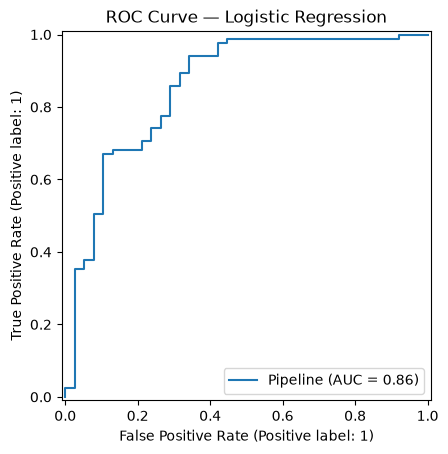

In [ ]:
# Step 6.3: Plot the ROC curve — a curve closer to the top-left corner means a better model
RocCurveDisplay.from_estimator(logreg_model, X_test, y_test)
plt.title("ROC Curve — Logistic Regression")
plt.show()

In [ ]:
# Step 6.4: Hyperparameter tuning — try different C values with 5-fold cross-validation
# C controls how strictly the model fits the training data:
# small C = simpler model (may underfit), large C = fits training data closely (may overfit)
# GridSearchCV tries every C value and picks the one with the best average accuracy
param_grid = {"logisticregression__C": [0.01, 0.1, 1, 10, 100]}  # C of the LogisticRegression step in the pipeline
grid = GridSearchCV(logreg_model, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)  # train and check each C value using 5-fold cross-validation

# Show the best C value found and how the tuned model performs
print("Best C:", grid.best_params_)
print("Best cross-validation accuracy:", round(grid.best_score_, 4))
print("Tuned model test accuracy:", round(grid.score(X_test, y_test), 4))

Best C: {'logisticregression__C': 0.01}
Best cross-validation accuracy: 0.7984
Tuned model test accuracy: 0.8537


In [ ]:
# Step 6.5: Robustness check — cross-validate the final tuned model on the full dataset
cv_scores = cross_val_score(grid.best_estimator_, X, y, cv=5, scoring="accuracy")
print("CV scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4))

CV scores: [0.813  0.7805 0.7805 0.8537 0.8197]
Mean CV accuracy: 0.8095


In [ ]:
# Step 6.6: Save the final tuned model — the Streamlit app in Step 7 will load this file
import joblib
final_model = grid.best_estimator_
joblib.dump(final_model, "loan_model.pkl")
print("Saved final model to loan_model.pkl")

Saved final model to loan_model.pkl
